<a href="https://colab.research.google.com/github/JamesTan44181/DLI-Group-Assignment/blob/main/GroupAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Each members model and group self-created code

## Setup


In [27]:
import numpy as np
import pandas as pd
import time
import gdown
import glob
from sklearn.preprocessing import OneHotEncoder
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import os
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score
from sklearn.utils import class_weight
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import UndefinedMetricWarning
import warnings

np.random.seed(42)
tf.random.set_seed(42)

## Data Loading**

The dataset is download from UNB but colab cannot directly access to the link. Hence, we upload into a public google drive to download by using the url. (IDS 2017 | Datasets | Research | Canadian Institute for Cybersecurity | UNB, n.d.)

In [28]:
# target file
data_dir = "CIC_IDS2017"
if not os.path.exists(data_dir):
    # Download zip file of dataset for whole dataset
    file_id = "1pMMlyzmJNvURynMO0_WztdIhl6oFPASo"
    url = f"https://drive.google.com/uc?id={file_id}"
    output = "CIC-IDS2017.zip"

    # Download for only Monday-WorkingHours.csv
    #file_id = "1p9vawaAKIMof7zZY2QP-AIZEYN0k9c1u"
    #url = f"https://drive.google.com/uc?id={file_id}"
    #output = "CICIDS2017.zip"
    gdown.download(url, output, quiet=False)

    # extract
    !unzip -q CIC-IDS2017.zip -d CIC_IDS2017
else:
    print("Dataset already exists, skip downloading.")

files = glob.glob("CIC_IDS2017/MachineLearningCVE/*.csv")

sampled_dfs = []

for file in files:
    print("Processing:", file)
    df = pd.read_csv(file)

    # get 40,000 in each csv
    df_sample = df.sample(n=min(40000, len(df)), random_state=42)

    sampled_dfs.append(df_sample)

# combine the data we need to used
df_combined = pd.concat(sampled_dfs, ignore_index=True)

print("Total rows after sampling:", len(df_combined))

# save
df_combined.to_csv("CICIDS2017_sampled.csv", index=False)
print("Saved to CICIDS2017_sampled.csv")

Dataset already exists, skip downloading.
Processing: CIC_IDS2017/MachineLearningCVE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Tuesday-WorkingHours.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Friday-WorkingHours-Morning.pcap_ISCX.csv
Total rows after sampling: 320000
Saved to CICIDS2017_sampled.csv


In [29]:
# To combine all CSV and show the first five rows
#csv_files = glob.glob('CIC_IDS2017/MachineLearningCVE/Monday-WorkingHours.csv')
#df_list = [pd.read_csv(f) for f in csv_files]
#df = pd.concat(df_list, ignore_index=True)
#df.head()
# To get only Monday-WorkingHours dataset on CIC-IDS2017 dataset
df_combined.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,77689,4,8,6134,153,4686,0,1533.5,2209.736862,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,443,3659078,10,9,717,5821,363,0,71.7,121.708258,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,44176,76,1,1,2,6,2,2,2.0,0.000000,...,24,0.0,0.0,0,0,0.0,0.0,0,0,PortScan
3,8641,81,1,1,6,6,6,6,6.0,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,1026,61,1,1,2,6,2,2,2.0,0.000000,...,24,0.0,0.0,0,0,0.0,0.0,0,0,PortScan


## Pre-processing

Data Cleaning

In [30]:
# Show the total row
print("Total rows before cleaning:", len(df_combined))

# Check duplicates
print("Total duplicate rows:", df_combined.duplicated().sum())

# Delete the duplicated row
df_combined.drop_duplicates(inplace=True)
#print("Total rows after dropping duplicates:", len(df))
# The total rows after dropping duplicates is same with total rows before, so no need this process.

# Check Infinite value
numeric_df = df_combined.select_dtypes(include=[np.number])
print("Total infinite values:", np.isinf(numeric_df.values).sum())

# Process the infinite value
df_combined = df_combined.replace([np.inf, -np.inf], np.nan)

# Check missing values
#print("Total missing values:", df.isna().sum().sum())
#print("Missing values per column (if any):")
#print(df.isna().sum())

# Fill the missing value
# Since there are huge dataset, we use pandas fillna to process this.
# Pandas fillna is faster than SimpleImputer
numeric_cols = df_combined.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_combined[col].isna().sum() > 0:
       df_combined[col] = df_combined[col].fillna(df_combined[col].median())

# Remove all the space after and before the columns name
df_combined.rename(columns=lambda x: x.strip(), inplace=True)

# Confirm the label types
print("Unique Labels:", df_combined['Label'].unique())

# Convert the unreadable text to readable
df_combined['Label'] = df_combined['Label'].replace({
    'Web Attack � Brute Force': 'Web Attack - Brute Force',
    'Web Attack � XSS': 'Web Attack - XSS',
    'Web Attack � Sql Injection': 'Web Attack - Sql Injection'
})

df_combined.to_csv("CIC_IDS2017_cleaned.csv", index=False)
print("Data cleaning complete, saved to CIC_IDS2017_cleaned.csv")
print("Total rows after cleaning:", len(df_combined))

Total rows before cleaning: 320000
Total duplicate rows: 14931
Total infinite values: 364
Unique Labels: ['BENIGN' 'PortScan' 'Infiltration' 'DDoS' 'Web Attack � Brute Force'
 'Web Attack � XSS' 'Web Attack � Sql Injection' 'SSH-Patator'
 'FTP-Patator' 'DoS Hulk' 'DoS Slowhttptest' 'DoS GoldenEye'
 'DoS slowloris' 'Heartbleed' 'Bot']
Data cleaning complete, saved to CIC_IDS2017_cleaned.csv
Total rows after cleaning: 305069


Train-test split

In [31]:
# Features and raw labels
X = df_combined.drop(columns=['Label']).values
y_raw = df_combined['Label'].values

# Train-test split
X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y_raw,
    test_size=0.2,
    random_state=42,
    stratify=y_raw
)

print("Train shape:", X_train.shape, y_train_raw.shape)
print("Test shape:", X_test.shape, y_test_raw.shape)


Train shape: (244055, 78) (244055,)
Test shape: (61014, 78) (61014,)


Balance Classes

In [32]:
# Total the label sample
#class_counts = df_combined['Label'].value_counts()
#print("Original class distribution:")
#print(class_counts)

# Find the label types which is existed the highest time
#majority_class = class_counts.idxmax()
#print("Majority class:", majority_class)

#Separate the highest existed label and anothers
#df_majority = df_combined[df_combined['Label'] == majority_class]
#df_minority = df_combined[df_combined['Label'] != majority_class]

#Undersample the majority class to match the total of the minority class (to maintain balance).
#df_majority_downsampled = resample(df_majority,
#                                   replace=False,
#                                   n_samples=len(df_minority),
#                                   random_state=42)

#df_balanced = pd.concat([df_majority_downsampled, df_minority])
#print("Balanced class distribution:")
#print(df_balanced['Label'].value_counts())

# Convert X_train to DataFrame and add Label
df_train = pd.DataFrame(X_train, columns=df_combined.columns[:-1])
df_train['Label'] = y_train_raw

# Identify majority class and minority classes
majority_class = df_train['Label'].value_counts().idxmax()
df_majority = df_train[df_train['Label'] == majority_class]
df_minority = df_train[df_train['Label'] != majority_class]

# Downsample majority class
df_majority_downsampled = resample(
    df_majority,
    replace=False,
    n_samples=len(df_minority),
    random_state=42
)

df_train_balanced = pd.concat([df_majority_downsampled, df_minority])
print("Balanced training class distribution:")
print(df_train_balanced['Label'].value_counts())

# Separate features and labels
X_train_bal = df_train_balanced.drop('Label', axis=1).values
y_train_bal_raw = df_train_balanced['Label'].values

Balanced training class distribution:
Label
BENIGN                        44706
DDoS                          18246
PortScan                      15744
DoS Hulk                       8228
FTP-Patator                     480
DoS GoldenEye                   452
Bot                             308
SSH-Patator                     302
Web Attack - Brute Force        291
DoS slowloris                   260
DoS Slowhttptest                255
Web Attack - XSS                131
Web Attack - Sql Injection        4
Infiltration                      3
Heartbleed                        2
Name: count, dtype: int64


Features scaling

In [33]:
scaler = StandardScaler()
X_train_bal_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

Label Encoding using One-Hot Encoding because the model we choose is neural network

In [34]:
# Print out all the column name
#print(df.columns.tolist())

# Remove all the space after and before the columns name
#df.rename(columns=lambda x: x.strip(), inplace=True)

# Confirm again the columns name
#print(df.columns.tolist())

# Confirm the label types
#print("Unique Labels:", df['Label'].unique())

# Convert the unreadable text to readable
#df['Label'] = df['Label'].replace({
#    'Web Attack � Brute Force': 'Web Attack - Brute Force',
#    'Web Attack � XSS': 'Web Attack - XSS',
#    'Web Attack � Sql Injection': 'Web Attack - Sql Injection'
#})
# Above put in data cleaning places

ohe = OneHotEncoder(sparse_output=False)
y_train_bal = ohe.fit_transform(y_train_bal_raw.reshape(-1,1))
y_test = ohe.transform(y_test_raw.reshape(-1,1))


Document features

In [35]:
# Feature summary
feature_names = df_train_balanced.drop(columns=['Label']).columns.tolist()
print(f"\nNumber of features: {len(feature_names)}")
print("Feature names (first 10):", feature_names[:10])

# Check feature types
print("\nFeature types:")
print(df_train_balanced.dtypes.value_counts())

# Class distribution
class_counts = df_train_balanced['Label'].value_counts()
print("\nClass distribution table:")
print(class_counts)


Number of features: 78
Feature names (first 10): ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']

Feature types:
float64    78
object      1
Name: count, dtype: int64

Class distribution table:
Label
BENIGN                        44706
DDoS                          18246
PortScan                      15744
DoS Hulk                       8228
FTP-Patator                     480
DoS GoldenEye                   452
Bot                             308
SSH-Patator                     302
Web Attack - Brute Force        291
DoS slowloris                   260
DoS Slowhttptest                255
Web Attack - XSS                131
Web Attack - Sql Injection        4
Infiltration                      3
Heartbleed                        2
Name: count, dtype: int64


## Model

### Define DNN （Group-self created)

In [36]:
dropout_rate = 0.3
neurons = [128, 64, 32]

model = Sequential()
# Define input with Input layer
model.add(Input(shape=(X_train.shape[1],)))

# First hidden layer
model.add(Dense(neurons[0], activation='relu'))
model.add(Dropout(dropout_rate))

# Second hidden layer
model.add(Dense(neurons[1], activation='relu'))
model.add(Dropout(dropout_rate))

# Third hidden layer
model.add(Dense(neurons[2], activation='relu'))
model.add(Dropout(dropout_rate))

# Output layer
model.add(Dense(y_train_bal.shape[1], activation='softmax'))

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_37 (Dense)                │ (None, 128)            │        10,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 15)             │           495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,943 (81.81 KB)

 Trainable params: 20,943 (81.81 KB)

 Non-trainable params: 0 (0.00 B)

### Define MLP (CY)

In [37]:
#1. WIthout same train model
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import f1_score, precision_score, recall_score

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Build MLP model
mlp_model = Sequential([
    Input(shape=(X_train_bal.shape[1],)),
    Dense(100, activation='relu'),
    Dropout(0.5),
    Dense(50, activation='relu'),
    Dropout(0.3),
    Dense(y_train_bal.shape[1], activation='softmax')
])

mlp_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mlp_model.summary()

# Early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = mlp_model.fit(
    X_train_bal, y_train_bal,
    epochs=100,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate on test set
test_loss, test_acc = mlp_model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

# Predictions
y_pred_prob = mlp_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# F1 Score (macro)
f1 = f1_score(y_true, y_pred, average="macro")
print(f"Macro F1 Score: {f1:.4f}")

# Macro-averaged precision and recall
precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
print(f"Macro Precision: {precision_macro:.4f}")
print(f"Macro Recall: {recall_macro:.4f}")

# Weighted-averaged precision and recall
precision_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)
print(f"Weighted Precision: {precision_weighted:.4f}")
print(f"Weighted Recall: {recall_weighted:.4f}")

#2. same train model
# Compute class weights
y_train_labels = y_train_bal_raw
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weights_dict = dict(enumerate(class_weights))

# Early stopping callback (optional)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = mlp_model.fit(
    X_train_bal,
    y_train_bal,
    validation_data=(X_test_scaled, y_test),
    epochs=5,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate on test set
test_loss, test_acc = mlp_model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

# Predictions
y_pred_prob = mlp_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

test_loss, test_acc = mlp_model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_41 (Dense)                │ (None, 100)            │         7,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 15)             │           765 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,715 (53.57 KB)

 Trainable params: 13,715 (53.57 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4567 - loss: 1215576.6250 - val_accuracy: 0.4023 - val_loss: 50102.5430
Epoch 2/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6376 - loss: 65430.1523 - val_accuracy: 0.5777 - val_loss: 11022.9590
Epoch 3/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6106 - loss: 20973.5645 - val_accuracy: 0.5418 - val_loss: 4597.2651
Epoch 4/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6038 - loss: 8939.1182 - val_accuracy: 0.5132 - val_loss: 3039.0852
Epoch 5/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6163 - loss: 5982.7549 - val_accuracy: 0.3040 - val_loss: 3016.5845
Epoch 6/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5926 - loss: 3275.6597 - val_accuracy: 0.3032 - val_loss: 1376.2035
Epoch 7/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5665 - loss: 2974.0803 - val_accuracy: 0.1797 - val_loss: 851.3974
Epoch 8/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/s

### Define CNN+BiLSTM+Transformer Model (Kok）

Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 78, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 78, 32)    │        128 │ input_layer_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_4     │ (None, 39, 32)    │          0 │ conv1d_5[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 39, 64)    │     16,640 │ max_pooling1d_4[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 39, 64)    │     33,216 │ bidirectional_2[… │
│ (MultiHeadAttentio… │                   │            │ bidirectional_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_14 (Add)        │ (None, 39, 64)    │          0 │ bidirectional_2[… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 39, 64)    │        128 │ add_14[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_44 (Dense)    │ (None, 128)       │      8,320 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_43          │ (None, 128)       │          0 │ dense_44[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_45 (Dense)    │ (None, 15)        │      1,935 │ dropout_43[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 60,367 (235.81 KB)

 Trainable params: 60,367 (235.81 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/4
2795/2795 ━━━━━━━━━━━━━━━━━━━━ 173s 60ms/step - accuracy: 0.7992 - loss: 0.5972 - val_accuracy: 0.9602 - val_loss: 0.1193
Epoch 2/4
2795/2795 ━━━━━━━━━━━━━━━━━━━━ 216s 65ms/step - accuracy: 0.9476 - loss: 0.1640 - val_accuracy: 0.9654 - val_loss: 0.1022
Epoch 3/4
2795/2795 ━━━━━━━━━━━━━━━━━━━━ 182s 58ms/step - accuracy: 0.9559 - loss: 0.1328 - val_accuracy: 0.9673 - val_loss: 0.0809
Epoch 4/4
2795/2795 ━━━━━━━━━━━━━━━━━━━━ 216s 63ms/step - accuracy: 0.9597 - loss: 0.1190 - val_accuracy: 0.9581 - val_loss: 0.1001
1907/1907 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step
Accuracy: 0.9580915855377454
Macro F1 Score: 0.54707421903394
Overall Precision: 0.5351091959153498
Overall Recall: 0.5848591325697721

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.97      0.97     49837
           1       0.66      0.30      0.41        77
           2       1.00      0.88      0.93      4562
           3       0.60      0.96      0.73       

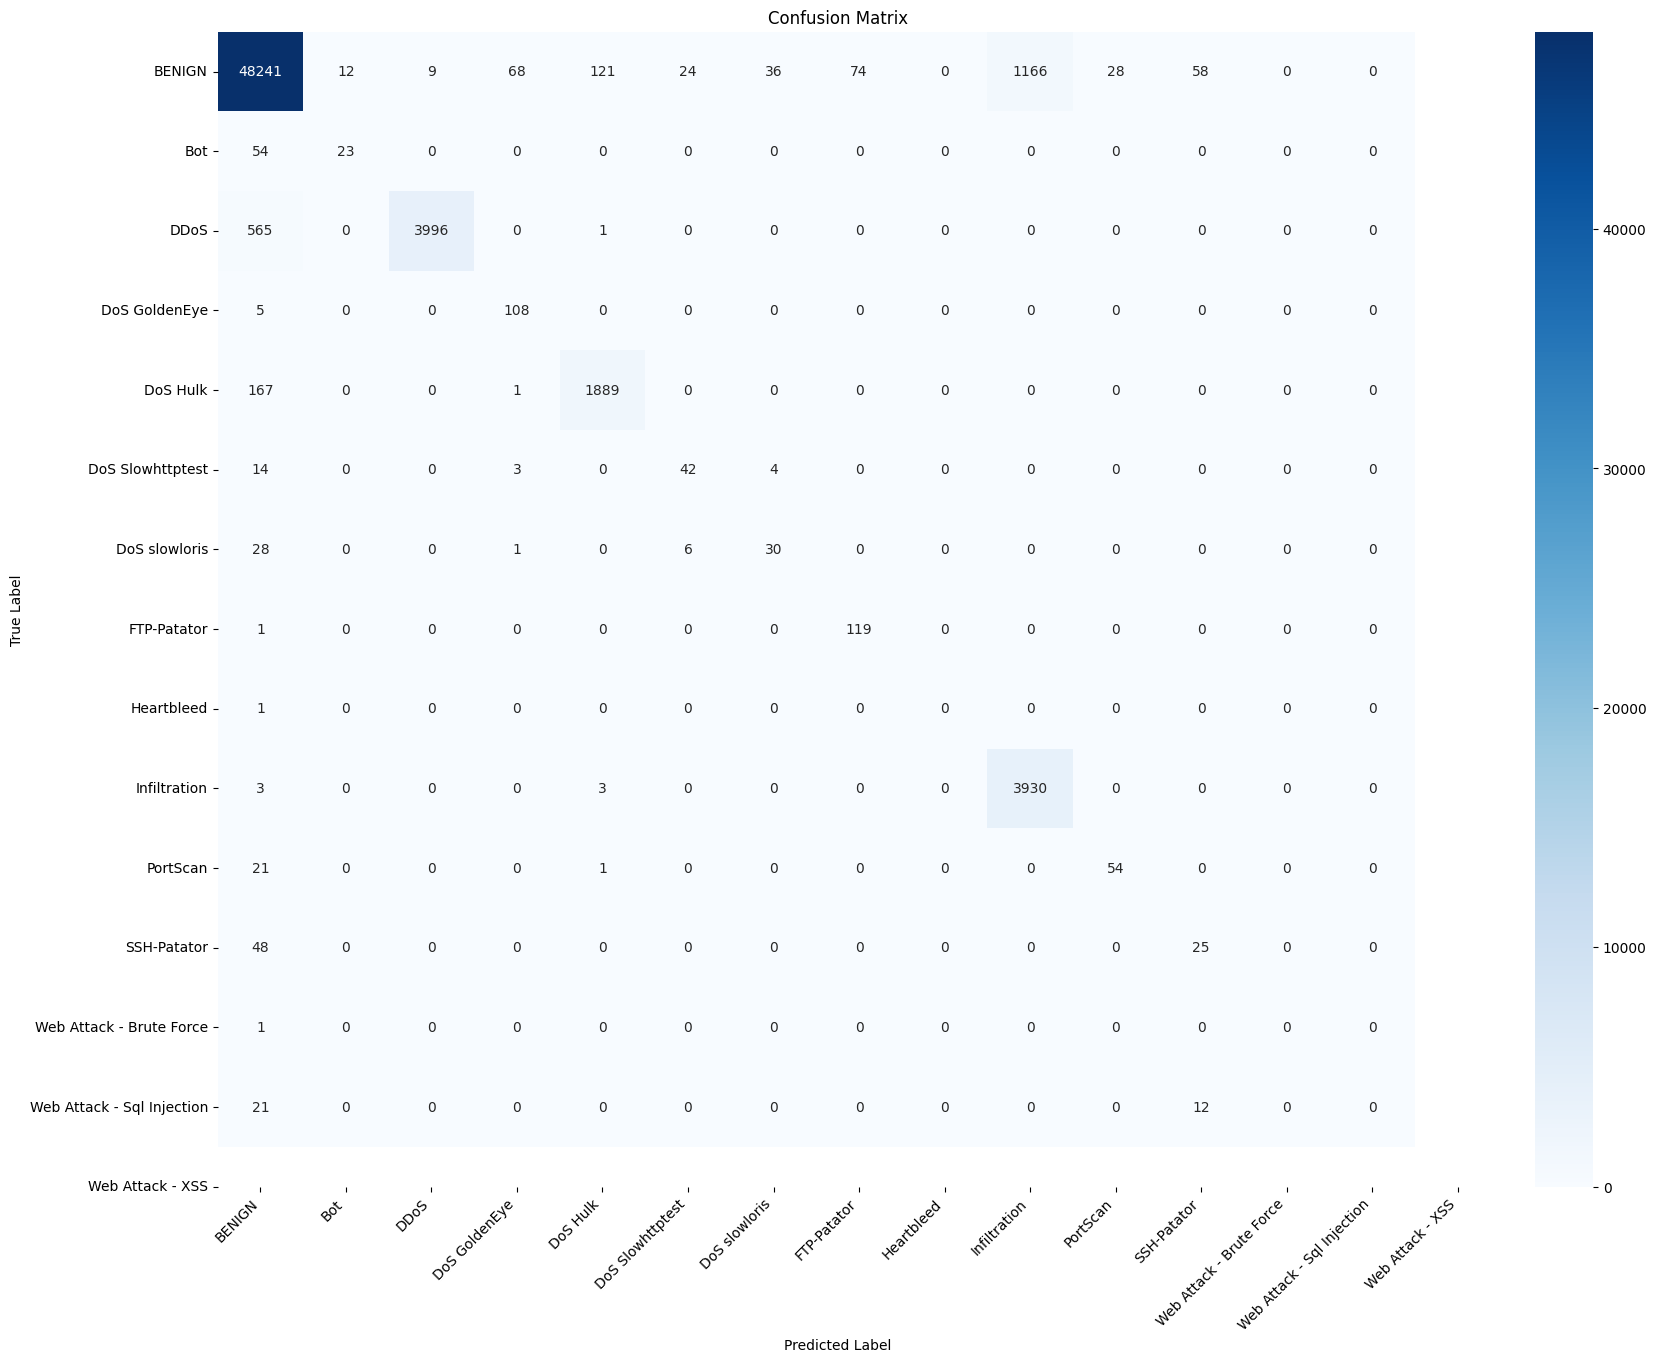

In [38]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Bidirectional, LSTM
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D
from tensorflow.keras.models import Model

# Reshape X_train for Conv1D/LSTM (expects 3D: [samples, timesteps, features])
X_train_reshaped = np.expand_dims(X_train, axis=-1)
X_test_reshaped = np.expand_dims(X_test, axis=-1)

# Input
inputs = Input(shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2]))

# --- CNN Block ---
x = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(inputs)
x = MaxPooling1D(pool_size=2)(x)

# --- BiLSTM Block ---
x = Bidirectional(LSTM(32, return_sequences=True))(x)

# --- Transformer Block ---
attn_output = MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
x = LayerNormalization(epsilon=1e-6)(x + attn_output)

# --- Pooling ---
x = GlobalAveragePooling1D()(x)

# --- Dense Layers (Simplified) ---
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

# --- Output Layer ---
outputs = Dense(y_train_bal.shape[1], activation='softmax')(x)

# Build Model
model = Model(inputs, outputs)

# Print model summary
model.summary()

# Set hyperparameters
learning_rate = 0.001
batch_size = 32
epochs = 4

# Compile
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

y_train_labels = y_train_bal_raw
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weights_dict = dict(enumerate(class_weights))

# Fit data
X_train_input = X_train_bal_scaled
y_train_input = y_train_bal

history = model.fit(
    X_train_input,
    y_train_input,
    validation_data=(X_test_scaled, y_test),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

# Predict probabilities
y_pred_probs = model.predict(X_test_scaled)

# Convert probabilities to class labels
y_pred = y_pred_probs.argmax(axis=1)
y_true = y_test.argmax(axis=1)  # y_test is one-hot

# Accuracy
accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy)

# Macro F1
macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
print("Macro F1 Score:", macro_f1)

# Overall Precision
overall_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
print("Overall Precision:", overall_precision)

# Overall Recall
overall_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
print("Overall Recall:", overall_recall)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
label_names = ohe.categories_[0]

plt.figure(figsize=(20, 15))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names,
            annot_kws={"size": 10})
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

### LTSM + ANN (Chuah)

Classes: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack - Brute Force', 'Web Attack - Sql Injection', 'Web Attack - XSS']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 141s 45ms/step - accuracy: 0.9107 - loss: 0.3414 - val_accuracy: 0.9837 - val_loss: 0.0593 - learning_rate: 0.0010
Epoch 2/10
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 140s 45ms/step - accuracy: 0.9819 - loss: 0.0742 - val_accuracy: 0.9844 - val_loss: 0.0557 - learning_rate: 0.0010
Epoch 3/10
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 133s 42ms/step - accuracy: 0.9860 - loss: 0.0581 - val_accuracy: 0.9882 - val_loss: 0.0464 - learning_rate: 0.0010
Epoch 4/10
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 142s 42ms/step - accuracy: 0.9873 - loss: 0.0500 - val_accuracy: 0.9886 - val_loss: 0.0391 - learning_rate: 0.0010
Epoch 5/10
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 128s 42ms/step - accuracy: 0.9888 - loss: 0.0429 - val_accuracy: 0.9912 - val_loss: 0.0308 - learning_rate: 0.0010
Epoch 6/10
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 143s 42ms/step - accuracy: 0.9897 - loss: 0.0382 - val_accuracy: 0.9923 - val_loss: 0.0276 - learning_rate: 0.0010
Epoch 7/10
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 128s 42ms/step -

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


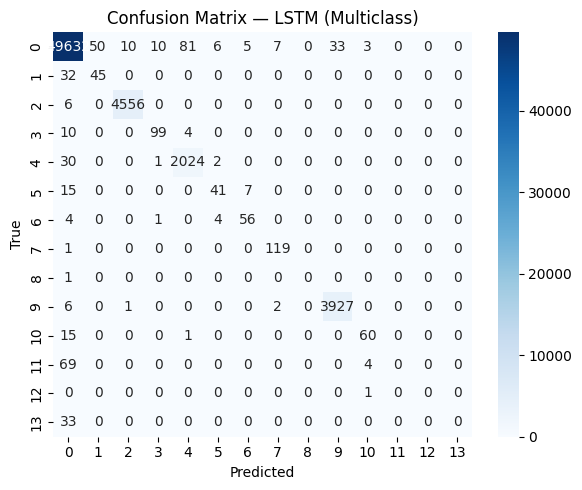

In [39]:
# --- Imports ---
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# --- 1) Train/Val/Test Split ---
X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y_raw,
    test_size=0.2,
    stratify=y_raw,
    random_state=42
)

X_tr, X_val, y_tr_raw, y_val_raw = train_test_split(
    X_train, y_train_raw,
    test_size=0.2,
    stratify=y_train_raw,
    random_state=42
)

# --- 2) One-Hot Encode Labels ---
enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
y_tr  = enc.fit_transform(y_tr_raw.reshape(-1,1))
y_val = enc.transform(y_val_raw.reshape(-1,1))
y_test = enc.transform(y_test_raw.reshape(-1,1))

num_classes = y_tr.shape[1]   # should be 15
print("Classes:", enc.categories_[0].tolist())

# --- 3) Reshape Features for LSTM ---
X_tr_3d  = X_tr.reshape(X_tr.shape[0],  X_tr.shape[1],  1)
X_val_3d = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_te_3d  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# --- 4) Define LSTM Model ---
lstm_model = Sequential([
    LSTM(64, input_shape=(X_tr_3d.shape[1], 1), return_sequences=False),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')   # multiclass output
])

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# --- 5) Callbacks ---
earlystop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reducelr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# --- 6) Train ---
history = lstm_model.fit(
    X_tr_3d, y_tr,
    validation_data=(X_val_3d, y_val),
    epochs=10, batch_size=64,
    callbacks=[earlystop, reducelr],
    verbose=1
)

# --- 7) Evaluate ---
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

y_proba = lstm_model.predict(X_te_3d)   # (N, 15)
y_pred  = y_proba.argmax(axis=1)        # class indices
y_true  = y_test.argmax(axis=1)         # class indices

acc = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

print("📊 Core Metrics (Macro)")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nClassification report (per class):")
print(classification_report(y_true, y_pred, digits=4))

# --- 8) Confusion Matrix ---
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — LSTM (Multiclass)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


### Define CNN Model （TWX)

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Reshape, Conv1D, BatchNormalization,
    MaxPooling1D, GlobalAveragePooling1D, Dropout, Dense
)

# Build CNN that accepts flat features and reshapes internally
model = Sequential([
    Input(shape=(X_train.shape[1],)),          # flat input like your DNN
    Reshape((X_train.shape[1], 1)),            # (timesteps/features, channels)

    # Conv blocks
    Conv1D(64, kernel_size=3, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(128, kernel_size=3, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(128, kernel_size=3, padding='same', activation='relu'),
    BatchNormalization(),

    # Head
    GlobalAveragePooling1D(),
    Dropout(0.3),

    Dense(y_train_bal.shape[1], activation='softmax')
])

model.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_1 (Reshape)             │ (None, 78, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 78, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 78, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 39, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 39, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 39, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 19, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 19, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 19, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,455 (302.56 KB)

 Trainable params: 76,815 (300.06 KB)

 Non-trainable params: 640 (2.50 KB)

### Define TabTransformer (Yap)

Epoch 1/10
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.9002 - loss: 0.3610 - val_accuracy: 0.9707 - val_loss: 0.0895
Epoch 2/10
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9704 - loss: 0.0869 - val_accuracy: 0.9717 - val_loss: 0.0788
Epoch 3/10
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9762 - loss: 0.0695 - val_accuracy: 0.9739 - val_loss: 0.0682
Epoch 4/10
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9786 - loss: 0.0601 - val_accuracy: 0.9729 - val_loss: 0.0697
Epoch 5/10
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.9803 - loss: 0.0551 - val_accuracy: 0.9752 - val_loss: 0.0554
Epoch 6/10
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9789 - loss: 0.0576 - val_accuracy: 0.9765 - val_loss: 0.0521
Epoch 7/10
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9815 - loss: 0.0503 - val_accuracy: 0.9727 - val_loss: 0.0683
Epoch 8/10
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9821 -

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


Core Metrics (Macro):
Accuracy:  0.9722
Precision: 0.5848
Recall:    0.6692
F1-score:  0.6164

Detailed Classification Report:
              precision    recall  f1-score   support

           0     0.9946    0.9726    0.9835     49837
           1     0.3833    0.2987    0.3358        77
           2     0.9976    0.9941    0.9958      4562
           3     0.9231    0.9558    0.9391       113
           4     0.9504    0.9315    0.9408      2057
           5     0.8116    0.8889    0.8485        63
           6     0.8696    0.9231    0.8955        65
           7     0.5459    0.9917    0.7041       120
           9     0.0000    0.0000    0.0000         1
          10     0.7951    0.9967    0.8846      3936
          11     0.6471    0.8684    0.7416        76
          12     0.2685    0.5479    0.3604        73
          13     0.0000    0.0000    0.0000         1
          14     0.0000    0.0000    0.0000        33

    accuracy                         0.9722     61014
   mac

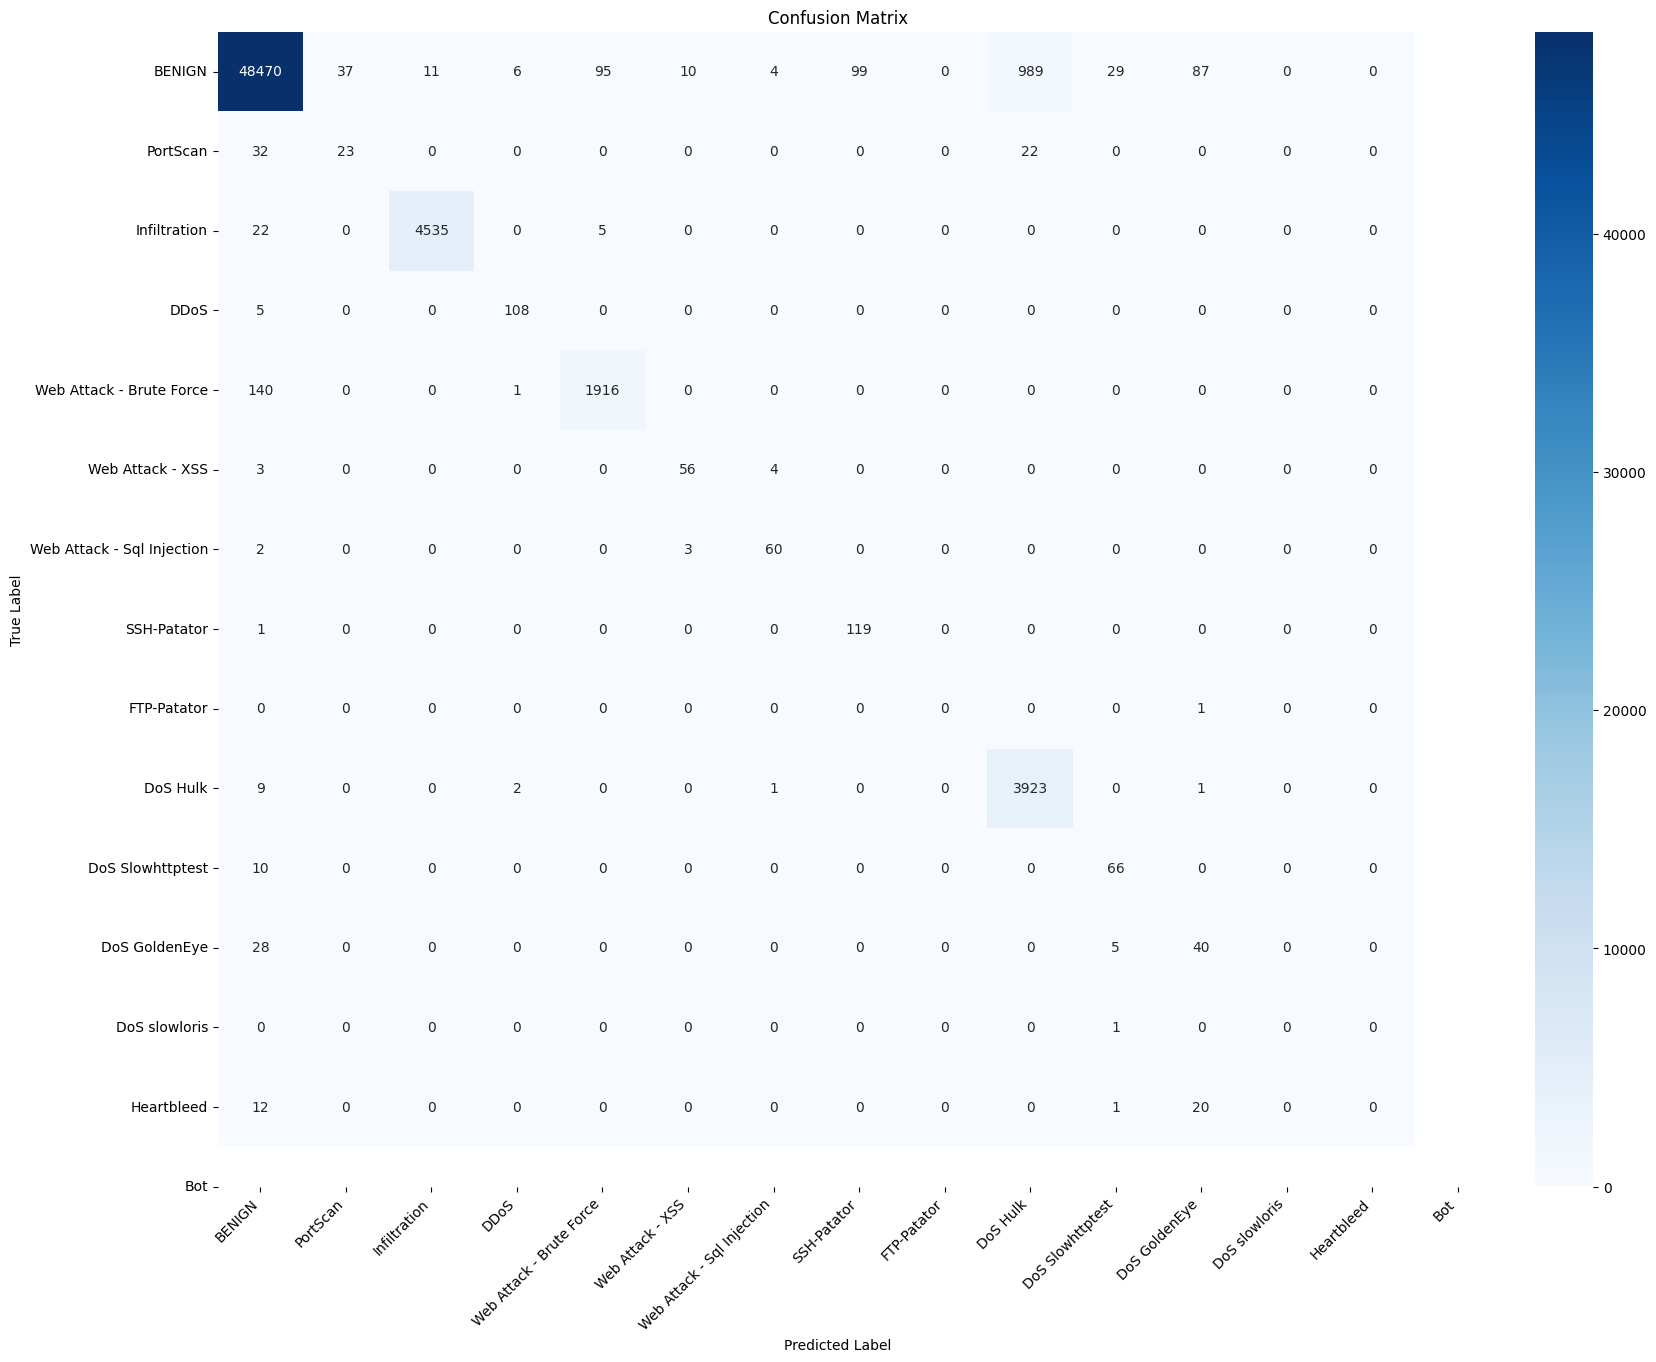

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


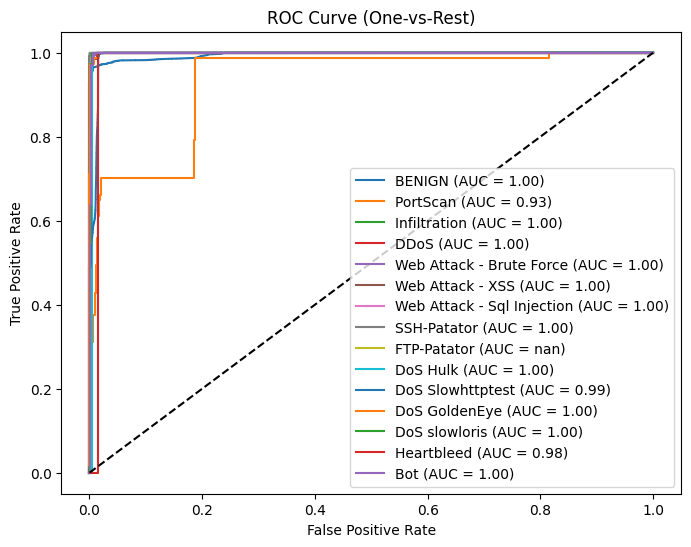

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


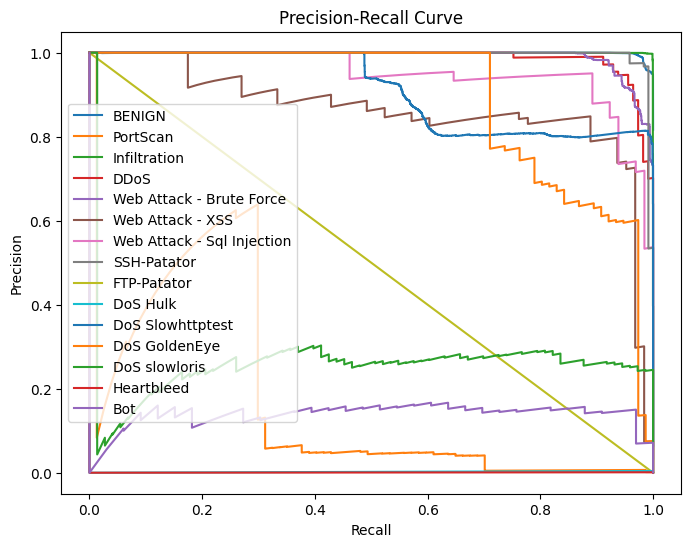

In [41]:

import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Embedding, Flatten, Dropout, LayerNormalization, MultiHeadAttention, Lambda
from tensorflow.keras.models import Model
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, precision_recall_fscore_support,
    roc_curve, auc, precision_recall_curve
)
from sklearn.utils import class_weight
from sklearn.preprocessing import label_binarize

# -------------------------------
# TabTransformer Block
# -------------------------------
def tab_transformer_block(inputs, n_heads=2, d_model=32, dropout=0.1):
    attn_output = MultiHeadAttention(num_heads=n_heads, key_dim=d_model)(inputs, inputs)
    attn_output = Dropout(dropout)(attn_output)
    out1 = LayerNormalization(epsilon=1e-6)(inputs + attn_output)

    ffn_output = Dense(d_model*4, activation='relu')(out1)
    ffn_output = Dense(d_model)(ffn_output)
    ffn_output = Dropout(dropout)(ffn_output)
    out2 = LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

    return out2

# -------------------------------
# TabTransformer Classifier
# -------------------------------
def build_tabtransformer_classifier(input_dim, num_classes, embed_dim=32, n_blocks=2):
    data_input = Input(shape=(input_dim,))
    x = Dense(embed_dim)(data_input)
    x = Lambda(lambda t: tf.expand_dims(t, axis=1))(x)  # shape -> (batch, 1, embed_dim)

    for _ in range(n_blocks):
        x = tab_transformer_block(x, n_heads=2, d_model=embed_dim)

    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(num_classes, activation='softmax')(x)

    return Model(data_input, output)

# -------------------------------
# Build and Compile
# -------------------------------
y_train_int = np.argmax(y_train_bal, axis=1)
y_test_int = np.argmax(y_test, axis=1)
num_classes = len(np.unique(y_train_int))
classifier = build_tabtransformer_classifier(input_dim=X_train_bal_scaled.shape[1], num_classes=num_classes)
classifier.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# -------------------------------
# Training
# -------------------------------
X_train_aug = np.vstack([X_train_bal_scaled])
y_train_aug = np.hstack([y_train_int])

history = classifier.fit(
    X_train_aug,
    tf.keras.utils.to_categorical(y_train_aug, num_classes=num_classes),
    batch_size=64,
    epochs=10,
    validation_split=0.1
)

# -------------------------------
# Evaluation
# -------------------------------
y_pred_prob = classifier.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)

precision, recall, f1, _ = precision_recall_fscore_support(y_test_int, y_pred, average="macro")
acc = accuracy_score(y_test_int, y_pred)

print("\nCore Metrics (Macro):")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test_int, y_pred, digits=4))

# -------------------------------
# Confusion Matrix
# -------------------------------
cm = confusion_matrix(y_test_int, y_pred)
class_names = df_combined['Label'].unique()

plt.figure(figsize=(20, 15))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 10})
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# -------------------------------
# ROC Curve (One-vs-Rest)
# -------------------------------
plt.figure(figsize=(8, 6))
for i, class_label in enumerate(class_names):
    fpr, tpr, _ = roc_curve((y_test_int == i).astype(int), y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_label} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC Curve (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# -------------------------------
# Precision-Recall Curve
# -------------------------------
plt.figure(figsize=(8, 6))
for i, class_label in enumerate(class_names):
    precision_curve, recall_curve, _ = precision_recall_curve((y_test_int == i).astype(int), y_pred_prob[:, i])
    plt.plot(recall_curve, precision_curve, label=f"{class_label}")

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

## Training

Set hyperparameters, compile the model, and fit it to the data.

In [42]:
# Set hyperparameters
learning_rate = 0.001
batch_size = 32
epochs = 5

# Compile
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

y_train_labels = y_train_bal_raw
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weights_dict = dict(enumerate(class_weights))

# Fit data
X_train_input = X_train_bal_scaled
y_train_input = y_train_bal

history = model.fit(
    X_train_input,
    y_train_input,
    validation_data=(X_test_scaled, y_test),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

Epoch 1/5
2795/2795 ━━━━━━━━━━━━━━━━━━━━ 69s 23ms/step - accuracy: 0.9298 - loss: 0.2920 - val_accuracy: 0.9890 - val_loss: 0.0368
Epoch 2/5
2795/2795 ━━━━━━━━━━━━━━━━━━━━ 81s 23ms/step - accuracy: 0.9779 - loss: 0.0702 - val_accuracy: 0.9680 - val_loss: 0.0921
Epoch 3/5
2795/2795 ━━━━━━━━━━━━━━━━━━━━ 81s 23ms/step - accuracy: 0.9809 - loss: 0.0580 - val_accuracy: 0.9726 - val_loss: 0.0857
Epoch 4/5
2795/2795 ━━━━━━━━━━━━━━━━━━━━ 64s 23ms/step - accuracy: 0.9837 - loss: 0.0496 - val_accuracy: 0.9783 - val_loss: 0.0676
Epoch 5/5
2795/2795 ━━━━━━━━━━━━━━━━━━━━ 82s 23ms/step - accuracy: 0.9846 - loss: 0.0466 - val_accuracy: 0.9898 - val_loss: 0.0325


## Evaluation


Prediction

In [43]:
# Predict probabilities
y_pred_probs = model.predict(X_test_scaled)

# Convert probabilities to class labels
y_pred = y_pred_probs.argmax(axis=1)
y_true = y_test.argmax(axis=1)  # y_test is one-hot

1907/1907 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step


Evaluation Metrics

Accuracy: 0.9897564493394958
Macro F1 Score: 0.6617150624947162
Overall Precision: 0.6568129442774246
Overall Recall: 0.7173811844049386

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     49837
           1       0.88      0.30      0.45        77
           2       1.00      1.00      1.00      4562
           3       0.90      0.98      0.94       113
           4       0.91      0.99      0.95      2057
           5       0.74      0.97      0.84        63
           6       0.79      0.91      0.84        65
           7       0.85      1.00      0.92       120
           9       0.00      0.00      0.00         1
          10       0.98      1.00      0.99      3936
          11       0.87      0.97      0.92        76
          12       0.28      0.93      0.42        73
          13       0.00      0.00      0.00         1
          14       0.00      0.00      0.00        33

    accuracy              

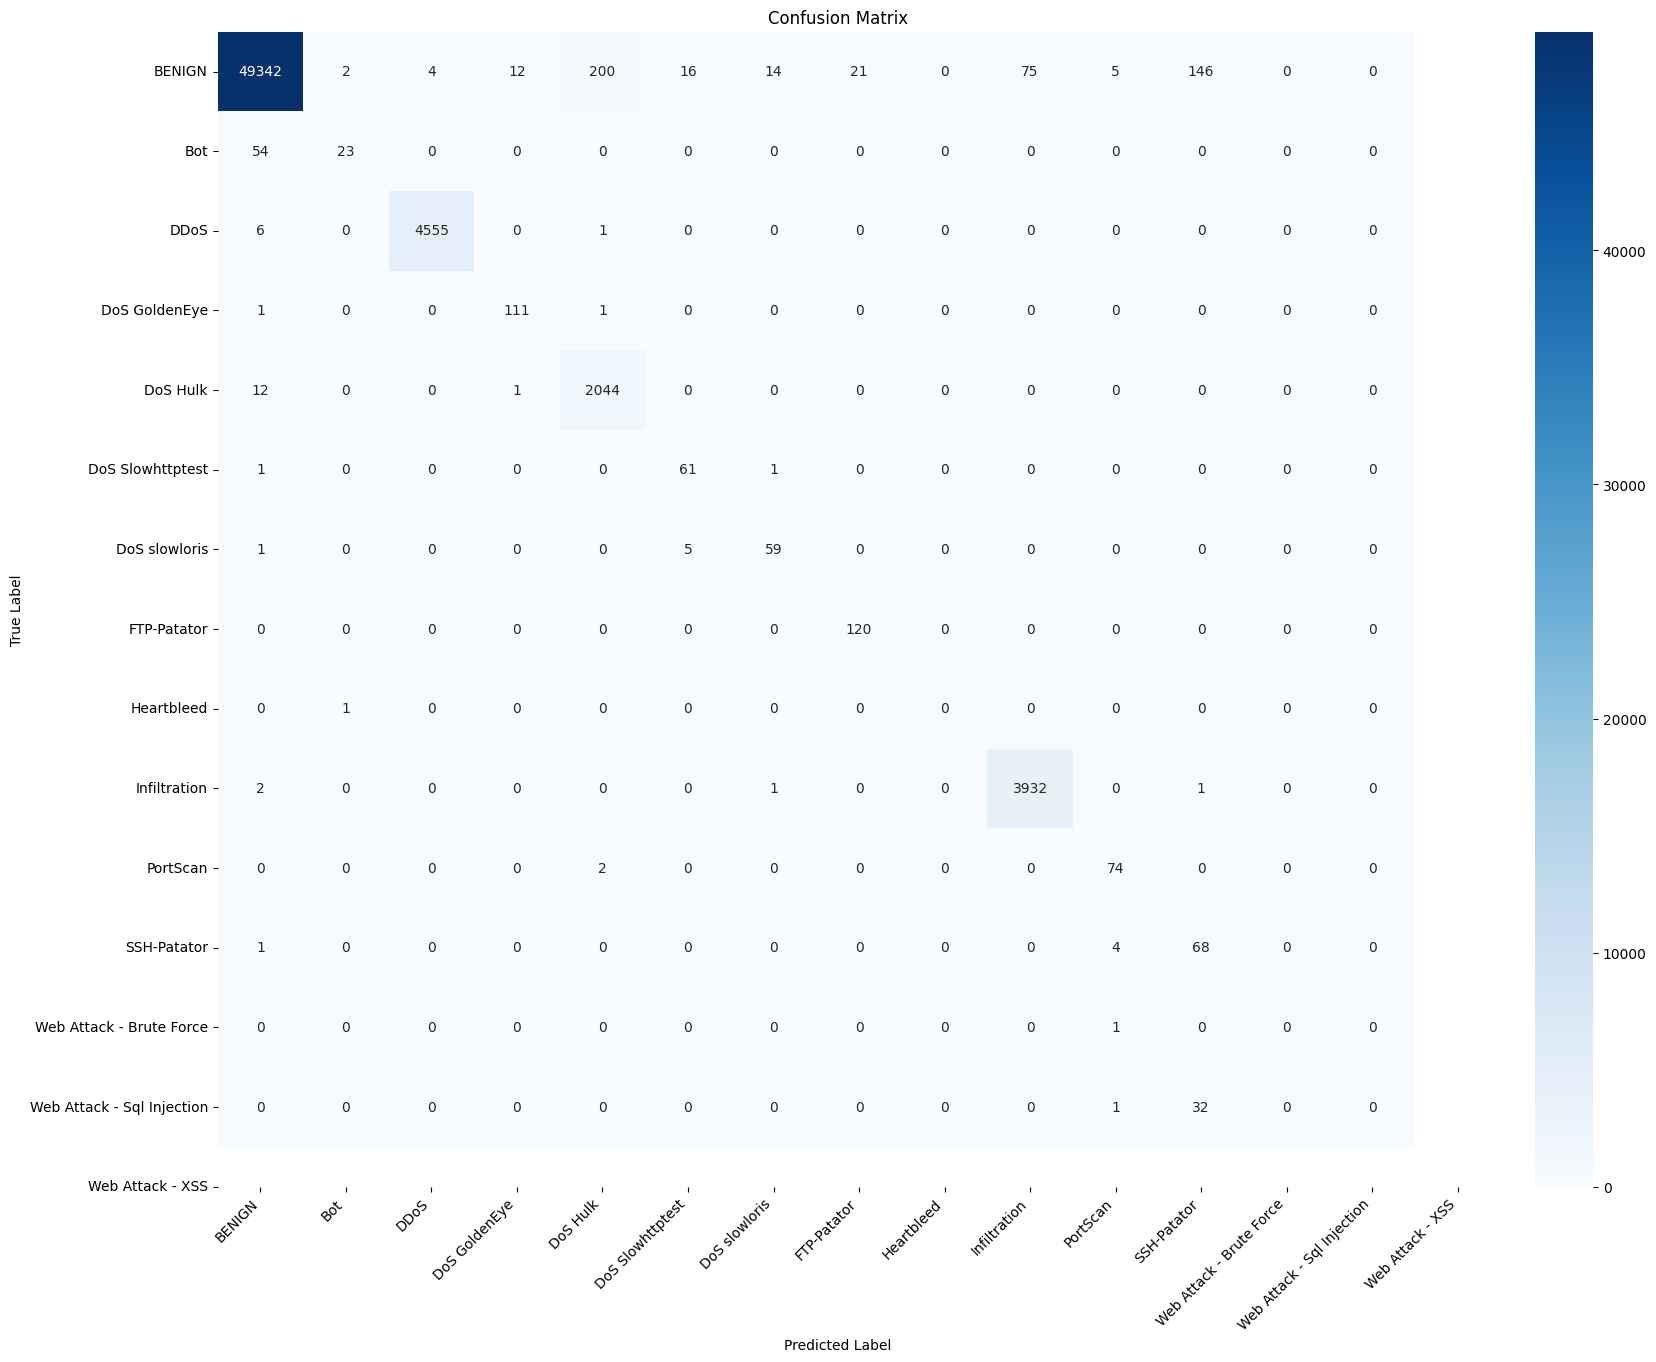

Weighted F1 Score: 0.9901862471800564
Cohen's Kappa Score: 0.9687044098127726


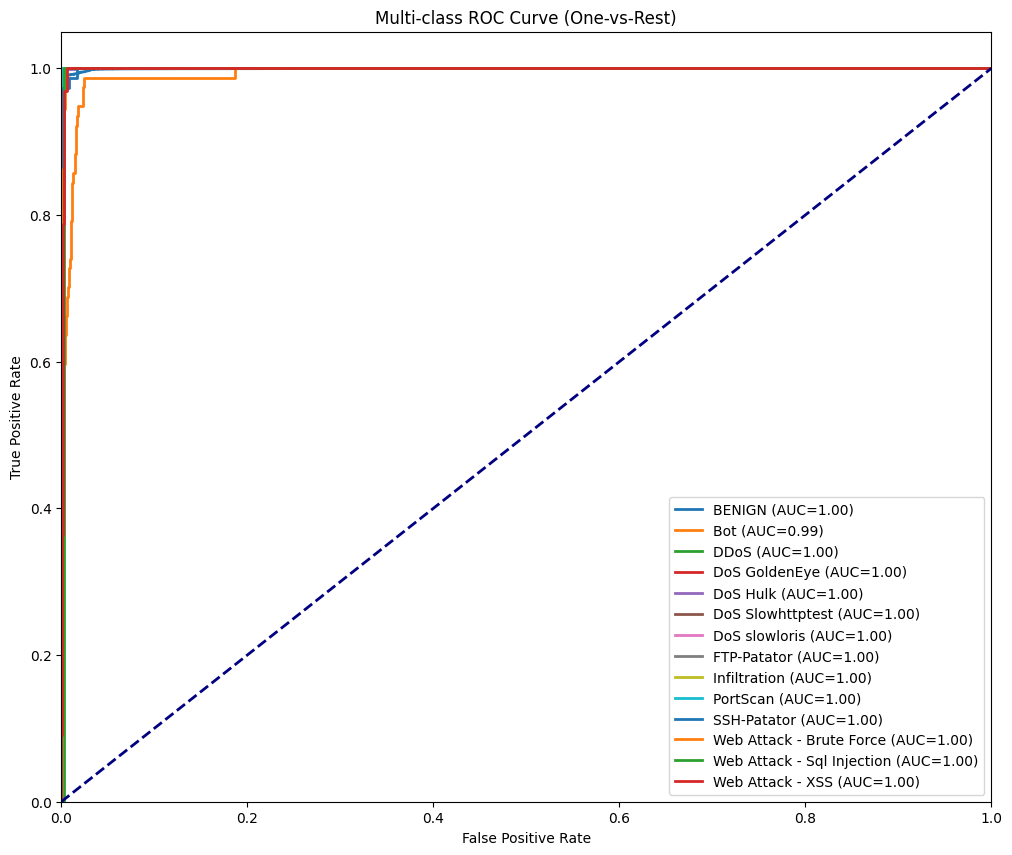

In [44]:
# Accuracy
accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy)

# Macro F1
macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
print("Macro F1 Score:", macro_f1)

# Overall Precision
overall_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
print("Overall Precision:", overall_precision)

# Overall Recall
overall_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
print("Overall Recall:", overall_recall)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
label_names = ohe.categories_[0]

plt.figure(figsize=(20, 15))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names,
            annot_kws={"size": 10})
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Weighted F1
weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
print("Weighted F1 Score:", weighted_f1)

# Cohen's Kappa
kappa = cohen_kappa_score(y_true, y_pred)
print("Cohen's Kappa Score:", kappa)

# Multi-class ROC Curve
n_classes = y_test.shape[1]
plt.figure(figsize=(12, 10))
for i in range(n_classes):
    if y_test[:, i].sum() == 0 or np.all(y_pred_probs[:, i] == 0):
        continue
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{label_names[i]} (AUC={roc_auc:.2f})')

plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (One-vs-Rest)')
plt.legend(loc="lower right")
plt.show()

## Save

Save the model

In [45]:
# Save model
model.save("cicids2017_model.keras")
print("Model saved as cicids2017_model.keras")

# Save test features
pd.DataFrame(X_test, columns=feature_names).to_csv("X_test.csv", index=False)
print("Test features saved as X_test.csv")

# Save test labels (convert from one-hot to integer)
y_labels = np.argmax(y_test, axis=1)
pd.DataFrame(y_labels, columns=['Label']).to_csv("y_test_labels.csv", index=False)
print("Test labels saved as y_test_labels.csv")

# Save feature names for reference
pd.DataFrame(feature_names, columns=['Feature']).to_csv("feature_names.csv", index=False)
print("Feature names saved as feature_names.csv")

Model saved as cicids2017_model.keras
Test features saved as X_test.csv
Test labels saved as y_test_labels.csv
Feature names saved as feature_names.csv


Verdict

In [46]:
print(f"Verdict: Achieved Accuracy = {accuracy:.4f}, Macro F1 = {macro_f1:.4f}. Overall performance is strong in terms of accuracy, but minority-class detection (precision/recall) could be improved.")


Verdict: Achieved Accuracy = 0.9898, Macro F1 = 0.6617. Overall performance is strong in terms of accuracy, but minority-class detection (precision/recall) could be improved.


# So, In the final comparason with our group self-created, and each of our models, the accuracy of LTSM+ANN is the highest. Hence, we choose it in our final.

# Final